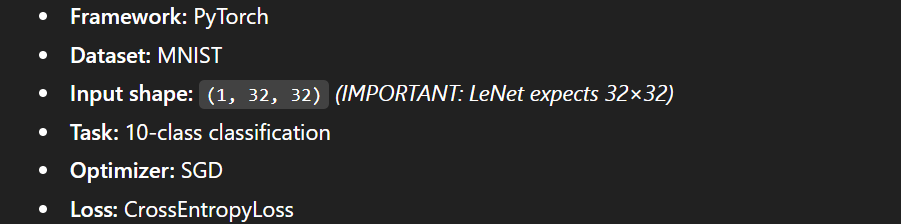

In [94]:
import torch
import torch
from torch import nn
from torch.utils.data import DataLoader , Dataset
from torchvision.datasets import MNIST
from torchvision import transforms

In [95]:
device = "cuda" if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")


Using cuda device


In [96]:
torch.manual_seed(42); torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

# Preparing and loading the Data

In [97]:
# Download training data from open datasets.
transform = transforms.Compose([
    transforms.Resize((32, 32)), # lenet expect 32x32
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) #For MNIST:  Mean pixel ≈ 0.1307  Std ≈ 0.3081
])

training_data = MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

# Download test data from open datasets.
test_data = MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform

)

In [98]:
batch_size = 64 

train_loader = DataLoader(training_data , batch_size=batch_size)
test_loader  = DataLoader(test_data , batch_size=batch_size)


In [99]:
X_train , y_train = next(iter(train_loader))
X_test , y_test = next(iter(test_loader))
print(X_train.shape , y_train.shape)
print(X_test.shape , y_test.shape)

torch.Size([64, 1, 32, 32]) torch.Size([64])
torch.Size([64, 1, 32, 32]) torch.Size([64])


# _________________________________________________________________________

# Creating model architecture 

# Lenet 5 Architecture

| Layer      | Type            | Operation            | Kernel / Pool | Stride | #Maps / Units | Input Size   | Output Size      |
| ---------- | --------------- | -------------------- | ------------- | ------ | ------------- | ------------ | ---------------- |
| **Input**  | Image           | Grayscale image      | –             | –      | 1             | 32 × 32 × 1  | 32 × 32 × 1      |
| **C1**     | Convolution     | Conv + tanh          | 5 × 5         | 1      | 6             | 32 × 32 × 1  | **28 × 28 × 6**  |
| **S2**     | Subsampling     | Avg Pool (learnable) | 2 × 2         | 2      | 6             | 28 × 28 × 6  | **14 × 14 × 6**  |
| **C3**     | Convolution     | Conv + tanh          | 5 × 5         | 1      | 16            | 14 × 14 × 6  | **10 × 10 × 16** |
| **S4**     | Subsampling     | Avg Pool (learnable) | 2 × 2         | 2      | 16            | 10 × 10 × 16 | **5 × 5 × 16**   |
| **C5**     | Convolution     | Conv + tanh          | 5 × 5         | 1      | 120           | 5 × 5 × 16   | **1 × 1 × 120**  |
| **F6**     | Fully Connected | Dense + tanh         | –             | –      | 84            | 120          | **84**           |
| **Output** | Classifier      | RBF / Softmax        | –             | –      | 10            | 84           | **10**           |


In [118]:
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1= nn.Sequential(
            nn.Conv2d(1 , 6 ,kernel_size=5 , stride=1 , padding = 0 ),
            nn.ReLU(),
            nn.AvgPool2d(2 ,2),
        )
        self.layer_2 = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            nn.AvgPool2d(2,2),
        )
        self.layer_3 = nn.Sequential(
            nn.Conv2d(16 , 120 , kernel_size=5 , stride=1 , padding=0)
        )
        self.fc_1 = nn.Linear(120, 84)
        self.fc_2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.layer_1(x)
        x = self.layer_2(x)
        x = self.layer_3(x)

        x = x.view(x.size(0), -1)
        x = torch.tanh(self.fc_1(x))
        x = self.fc_2(x)            

        return x

In [119]:
# Model summary

In [120]:
from torchinfo import summary

summary(
    LeNet5(),
    input_size=(1, 1, 32, 32),
    col_names=["input_size", "output_size", "num_params"],
    verbose=1,
);

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
LeNet5                                   [1, 1, 32, 32]            [1, 10]                   --
├─Sequential: 1-1                        [1, 1, 32, 32]            [1, 6, 14, 14]            --
│    └─Conv2d: 2-1                       [1, 1, 32, 32]            [1, 6, 28, 28]            156
│    └─ReLU: 2-2                         [1, 6, 28, 28]            [1, 6, 28, 28]            --
│    └─AvgPool2d: 2-3                    [1, 6, 28, 28]            [1, 6, 14, 14]            --
├─Sequential: 1-2                        [1, 6, 14, 14]            [1, 16, 5, 5]             --
│    └─Conv2d: 2-4                       [1, 6, 14, 14]            [1, 16, 10, 10]           2,416
│    └─ReLU: 2-5                         [1, 16, 10, 10]           [1, 16, 10, 10]           --
│    └─AvgPool2d: 2-6                    [1, 16, 10, 10]           [1, 16, 5, 5]             --
├─Sequential: 1-3              

# Training Loop

In [121]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    model.train()

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        #  Forward pass
        preds = model(X)
        loss = loss_fn(preds, y)

        #  Backward pass
        loss.backward()

        #  Update parameters
        optimizer.step()

        if batch % 100 == 0:
            loss_val = loss.item()
            current = batch * len(X)
            print(f"loss: {loss_val:.6f} [{current}/{size}]")


# ___________________________________________________________________________________

# Testing Loop

In [122]:
def test(dataloader, model, loss_fn, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.eval()

    test_loss = 0.0
    correct = 0

    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            # Forward pass
            preds = model(X)
            loss = loss_fn(preds, y)

            # Accumulate loss & accuracy
            test_loss += loss.item()
            correct += (preds.argmax(1) == y).sum().item()

    test_loss /= num_batches
    accuracy = correct / size

    print(
        f"Test Error:\n"
        f" Accuracy: {(100 * accuracy):.1f}%\n"
        f" Avg loss: {test_loss:.6f}\n"
    )


# ________________________________________________________________________________________

# Training and Parameter 

In [127]:
lr = 0.01
epochs = 10
model = LeNet5().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

In [128]:
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_loader, model, loss_fn, optimizer , device = device)
    test(test_loader, model, loss_fn, device=device)
print("Done!")

Epoch 1
-------------------------------
loss: 2.304325 [0/60000]
loss: 0.315700 [6400/60000]
loss: 0.180149 [12800/60000]
loss: 0.224488 [19200/60000]
loss: 0.113823 [25600/60000]
loss: 0.066480 [32000/60000]
loss: 0.097283 [38400/60000]
loss: 0.150638 [44800/60000]
loss: 0.308746 [51200/60000]
loss: 0.136088 [57600/60000]
Test Error:
 Accuracy: 97.1%
 Avg loss: 0.101040

Epoch 2
-------------------------------
loss: 0.048575 [0/60000]
loss: 0.097090 [6400/60000]
loss: 0.076098 [12800/60000]
loss: 0.160830 [19200/60000]
loss: 0.017338 [25600/60000]
loss: 0.077511 [32000/60000]
loss: 0.108945 [38400/60000]
loss: 0.137543 [44800/60000]
loss: 0.188803 [51200/60000]
loss: 0.084886 [57600/60000]
Test Error:
 Accuracy: 98.5%
 Avg loss: 0.053005

Epoch 3
-------------------------------
loss: 0.016989 [0/60000]
loss: 0.077710 [6400/60000]
loss: 0.079917 [12800/60000]
loss: 0.110177 [19200/60000]
loss: 0.012577 [25600/60000]
loss: 0.079481 [32000/60000]
loss: 0.114887 [38400/60000]
loss: 0.0979

In [129]:
wrong_images = []
wrong_preds = []
wrong_labels = []

model.eval()
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        preds = model(X).argmax(1)

        mask = preds != y
        if mask.any():
            wrong_images.append(X[mask].cpu())
            wrong_preds.append(preds[mask].cpu())
            wrong_labels.append(y[mask].cpu())

# concatenate
wrong_images = torch.cat(wrong_images)
wrong_preds  = torch.cat(wrong_preds)
wrong_labels = torch.cat(wrong_labels)


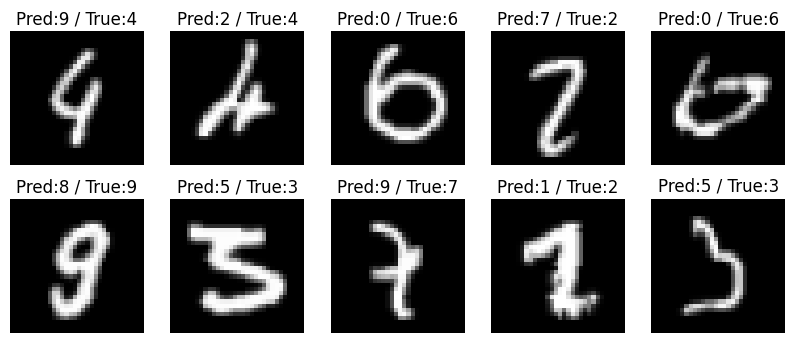

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(wrong_images[i][0], cmap="gray")
    plt.title(f"Pred:{wrong_preds[i]} / True:{wrong_labels[i]}")
    plt.axis("off")
plt.show()


In [134]:
from collections import Counter
pairs = list(zip(wrong_labels.tolist(), wrong_preds.tolist()))
print(Counter(pairs).most_common(10))

[((4, 9), 8), ((3, 5), 7), ((6, 5), 7), ((6, 0), 6), ((9, 7), 5), ((9, 8), 4), ((6, 8), 4), ((5, 3), 4), ((2, 7), 3), ((8, 9), 3)]


Most errors are visually ambiguous even for humans:
4↔9, 6↔0, 3↔5, 2↔7, 1↔7

The model’s predictions are reasonable, not random.

This indicates representation limits of LeNet-5, not training or optimization issues.

LeNet-5 has learned meaningful features; remaining errors are due to handwriting ambiguity, not model failure.

In [ ]:
"""Why AvgPool instead of MaxPool?
LeNet was designed for smooth feature averaging; AvgPool preserves overall shape information, while MaxPool is more aggressive.

Why C5 uses 5×5 kernel?
At that stage the feature map is 5×5, so a 5×5 kernel covers the entire spatial area, acting like a fully connected layer.

Why LeNet generalizes well with few parameters?
Small kernels, weight sharing, and pooling drastically reduce parameters and overfitting.

What breaks if input is 28×28?
Spatial sizes shrink too much → C5 no longer gets a 5×5 map, causing shape mismatch. """